<a href="https://colab.research.google.com/github/GeemaInduruwage/computer-vision-assignment-2/blob/main/Question01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor

# Creating the lines.csv file based on the provided table data
data = {
    'x1': [-5.3055, -5.5404, -4.9821, -4.4957, -4.4422],
    'x2': [-4.0601, -5.0032, -4.5845, -5.0641, -4.4114],
    'x3': [-5.2613, -3.9926, -4.3312, -4.7820, -4.5675],
    'y1': [-12.6663, -11.0077, -11.6973, -11.9780, -12.4150],
    'y2': [-3.7962, -3.9856, -3.5893, -3.5971, -2.7995],
    'y3': [3.6917, 4.9000, 5.0469, 4.6359, 4.7397]
}
df = pd.DataFrame(data)
df.to_csv('lines.csv', index=False)
print('lines.csv created successfully.')

lines.csv created successfully.


### Part (a): Total Least Squares (TLS)
TLS minimizes the orthogonal distances from the points to the line. We can solve this using SVD on the centered data.

In [3]:
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)
x1 = D[:, 0]
y1 = D[:, 3]

def total_least_squares(x, y):
    # Center the data
    x_mean, y_mean = np.mean(x), np.mean(y)
    points = np.vstack([x - x_mean, y - y_mean]).T

    # SVD
    _, _, vh = np.linalg.svd(points)
    # The normal to the line is the last row of vh
    a, b = vh[-1]

    # Line equation: a(x - x_mean) + b(y - y_mean) = 0
    # y = (-a/b)x + (a/b*x_mean + y_mean)
    slope = -a / b
    intercept = (a / b) * x_mean + y_mean
    return slope, intercept

slope_a, intercept_a = total_least_squares(x1, y1)
print(f'Part (a) Results - Slope: {slope_a:.4f}, Intercept: {intercept_a:.4f}')

Part (a) Results - Slope: -1.8640, Intercept: -21.1855


### Explanation: Total Least Squares (TLS)
Standard Ordinary Least Squares (OLS) assumes that only the dependent variable (y) contains noise. However, in many real-world scenarios, both x and y are subject to measurement error.

**Total Least Squares** addresses this by minimizing the **orthogonal distances** (perpendicular distances) from the points to the fitted line, rather than just the vertical distances. In the code above, we use **Singular Value Decomposition (SVD)** to find the direction of least variance, which defines the normal vector to the best-fitting line.

### Part (b): Sequential RANSAC
We combine all points and iteratively find and mask the consensus sets.

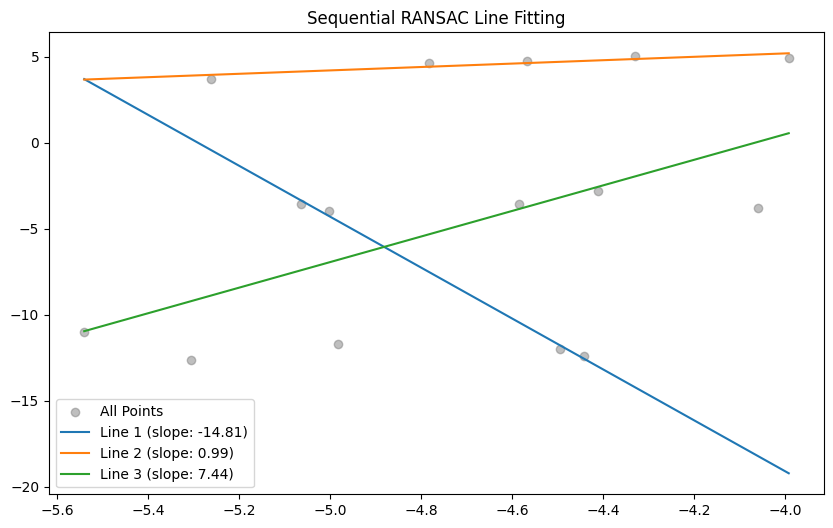

Line 1: y = -14.8055x + -78.3392
Line 2: y = 0.9879x + 9.1344
Line 3: y = 7.4357x + 30.2304


In [4]:
X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten().reshape(-1, 1)
Y_all = Y_cols.flatten()

current_X = X_all.copy()
current_Y = Y_all.copy()

lines = []

plt.figure(figsize=(10, 6))
plt.scatter(X_all, Y_all, color='gray', label='All Points', alpha=0.5)

for i in range(3):
    ransac = RANSACRegressor(residual_threshold=0.5)
    ransac.fit(current_X, current_Y)

    inlier_mask = ransac.inlier_mask_
    outlier_mask = ~inlier_mask

    # Store parameters
    line_slope = ransac.estimator_.coef_[0]
    line_intercept = ransac.estimator_.intercept_
    lines.append((line_slope, line_intercept))

    # Plot
    line_x = np.array([np.min(X_all), np.max(X_all)]).reshape(-1, 1)
    line_y = ransac.predict(line_x)
    plt.plot(line_x, line_y, label=f'Line {i+1} (slope: {line_slope:.2f})')

    # Mask consensus set for next iteration
    current_X = current_X[outlier_mask]
    current_Y = current_Y[outlier_mask]

plt.title('Sequential RANSAC Line Fitting')
plt.legend()
plt.show()

for i, (m, c) in enumerate(lines):
    print(f'Line {i+1}: y = {m:.4f}x + {c:.4f}')

### Explanation: Sequential RANSAC
**RANSAC (Random Sample Consensus)** is an iterative method used to estimate parameters of a mathematical model from a set of observed data that contains outliers.

In this multi-line problem, we use **Sequential RANSAC**:
1. **Fit**: Run RANSAC on the current dataset to find the best line (the one with the most 'inliers').
2. **Extract**: Identify all points that fit this line within a certain threshold.
3. **Mask**: Remove these 'inlier' points from the dataset so they aren't reused.
4. **Repeat**: Run RANSAC again on the remaining 'outliers' to find the next line. This continues until the desired number of lines is found.